<a href="https://colab.research.google.com/github/GuFerreiraV/notebooks_google_colab/blob/main/CDAM_Atividade_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ciência de Dados e Aprendizado de Máquina

# Atividade 2 - Classificação - ScikitLearn

## Aplicando os conceitos em dados reais

Nome Completo: Gustavo Ferreira Vargens

RGM: 31778496

Data: 29/09/2025

### Importação e preparação dos dados

In [1]:
from sklearn.datasets import load_digits

Importe o pacote **datasets** da biblioteca **sklearn**, então carregue o dataset de imagens de dígitos, utilizando a função **load_digits()** do pacote de datasets importado, já atribuindo-o à variável **digits_dataset**.

In [2]:
digits_dataset = load_digits()

Tendo feito o processo adequadamente, a variável **digits_dataset** conterá todo o dataset correspondente, inclusive com informações que não são de nosso interesse para esta atividade. Para selecionar apenas o que é de nosso interesse, atribua à variável **digits_img** apenas o objeto **images** de **digits_dataset**.

In [3]:
digits_img = digits_dataset.images

Verifique o formato de **digits_img**.

In [4]:
print(type(digits_img))

<class 'numpy.ndarray'>


Imprima **digits_img** para que seja possível ver como são os dados que temos no momento.

In [5]:
print(digits_img)

[[[ 0.  0.  5. ...  1.  0.  0.]
  [ 0.  0. 13. ... 15.  5.  0.]
  [ 0.  3. 15. ... 11.  8.  0.]
  ...
  [ 0.  4. 11. ... 12.  7.  0.]
  [ 0.  2. 14. ... 12.  0.  0.]
  [ 0.  0.  6. ...  0.  0.  0.]]

 [[ 0.  0.  0. ...  5.  0.  0.]
  [ 0.  0.  0. ...  9.  0.  0.]
  [ 0.  0.  3. ...  6.  0.  0.]
  ...
  [ 0.  0.  1. ...  6.  0.  0.]
  [ 0.  0.  1. ...  6.  0.  0.]
  [ 0.  0.  0. ... 10.  0.  0.]]

 [[ 0.  0.  0. ... 12.  0.  0.]
  [ 0.  0.  3. ... 14.  0.  0.]
  [ 0.  0.  8. ... 16.  0.  0.]
  ...
  [ 0.  9. 16. ...  0.  0.  0.]
  [ 0.  3. 13. ... 11.  5.  0.]
  [ 0.  0.  0. ... 16.  9.  0.]]

 ...

 [[ 0.  0.  1. ...  1.  0.  0.]
  [ 0.  0. 13. ...  2.  1.  0.]
  [ 0.  0. 16. ... 16.  5.  0.]
  ...
  [ 0.  0. 16. ... 15.  0.  0.]
  [ 0.  0. 15. ... 16.  0.  0.]
  [ 0.  0.  2. ...  6.  0.  0.]]

 [[ 0.  0.  2. ...  0.  0.  0.]
  [ 0.  0. 14. ... 15.  1.  0.]
  [ 0.  4. 16. ... 16.  7.  0.]
  ...
  [ 0.  0.  0. ... 16.  2.  0.]
  [ 0.  0.  4. ... 16.  2.  0.]
  [ 0.  0.  5. ... 12.  0.  

Sabendo que esta estrutura se refere a um conjunto de imagens, pode ser interessante imprimir ao menos uma ou duas para visualizarmos como é o seu padrão.

Para fazer isso, importe o pacote de funções **pyplot** da biblioteca **matplotlib**. Apesar de não ser obrigatório, para facilitar, recomenda-se utilizar um "apelido" para esse tipo de pacote com nome tão grande, a fim de tornar o seu uso mais prático. É comum utilizar o termo "plt" para o pyplot, mas você pode chamar como preferir.

In [6]:
from matplotlib import pyplot as plt

Depois de importar o pacote, utilize a função **imshow()** do **pyplot** para imprimir na tela uma das imagens contidas em **digits_img**.

Obs: caso tenha sido utilizado um apelido na importação do pacote, lembre-se dele quando for chamar suas funções, como é o caso agora.

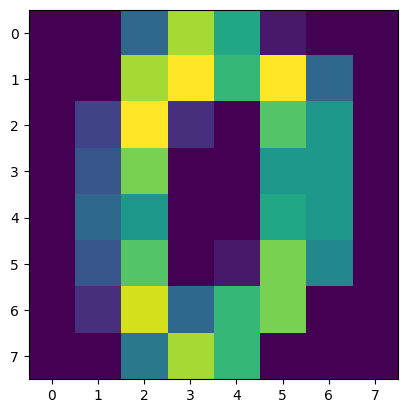

In [7]:
plt.imshow(digits_img[0])

Apesar de esse tipo de formato permitir que essas imagens sejam elegantemente exibidas, não se trata de um formato tão interessante para se efetuar processamentos computacionais. Por isso, faça uma mudança no formato da estrutura utilizando a função **reshape()** da biblioteca **numpy**. Como tal biblioteca ainda não foi importada, comece por sua importação, preferencialmente utilizando o apelido "np" para tornar mais prática a sua utilização.

In [8]:
import numpy as np
from numpy import reshape

Agora, com a biblioteca já importada, utilize a função **reshape()** para forçar um formato unidimensional para cada imagem dentro da matriz original.

Note que o número de imagens não pode ser alterado, tampouco as imagens em si; apenas o formato da representação de cada uma dessas imagens pode sofrer alteração.

In [9]:
reshape_image = digits_img.reshape(1797, 64)
print(reshape_image)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


Agora verifique se o novo formato está como desejava-se obter. Se o novo formato for bidimensional, o número de imagens for o mesmo que o original e o número de pixels for o mesmo que o original, então está correto.

In [10]:
print(reshape_image)

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]


Agora que já temos os dados de entrada adequadamente preparados, precisamos dos dados de saída correspondentes. Então, atribua o objeto **target** de **digits_dataset** à variável **digits_target**.

In [11]:
digits_target = digits_dataset.target

Imprima **digits_target** para visualizar como são esses dados

In [12]:
print(digits_target)

[0 1 2 ... 8 9 8]


Agora imprima o formato de **digits_target** para saber exatamente as suas dimensões.

In [13]:
print(type(digits_target))
print(digits_target.shape)

<class 'numpy.ndarray'>
(1797,)


#### Divisão dos dados em grupos para treinamento e teste.

Importe a função **train_test_split()** do pacote **model_selection**, pertencente à biblioteca **sklearn**.

In [14]:
from sklearn.model_selection import train_test_split

Agora, utilizando a função **train_test_split()**, divida os dados de entrada e saída, **digits** e **digits_target**, respectivamente, separando-os em dados de treinamento e de testes para entrada e saída, ou seja, **x_train**, **x_test**, **y_train** e **y_test**.

Separe 25% para testes utilizando o argumento *test_size* da própria função **train_test_split()**.

In [15]:
x_train, x_test, y_train, y_test = train_test_split(reshape_image, digits_target, test_size=0.25, random_state=45)

Imprima, em diferentes células, o formato de cada uma das partes obtidas.

In [16]:
print(type(x_train))
print(x_train.shape)

<class 'numpy.ndarray'>
(1347, 64)


In [17]:
print(type(x_test))
print(x_test.shape)

<class 'numpy.ndarray'>
(450, 64)


In [18]:
print(type(y_train))
print(y_train.shape)

<class 'numpy.ndarray'>
(1347,)


In [19]:
print(type(y_test))
print(y_test.shape)

<class 'numpy.ndarray'>
(450,)


### K-Nearest Neighbors (KNN)

#### Treinamento

Importe o classificador do KNN, que é uma função chamada **KNeighborsClassifier** do pacote **neighbors**, que faz parte da biblioteca **sklearn**.

In [20]:
from sklearn.neighbors import KNeighborsClassifier

Agora crie o classificador com o nome **knn** utilizando para o argumento *n_neighbors* da função **KNeighborsClassifier** o número de vizinhos próximos que serão considerados pelo algoritmo. Lembre-se de preferir um número ímpar não muito grande.

In [21]:
knn = KNeighborsClassifier(n_neighbors=5)

Treine o classificador **knn** por meio de sua própria função **fit()**, atribuindo o resultado ao próprio **knn**. Os argumentos da função **fit()** são os dados de entrada e saída de treinamento, ou seja, **x_train** e **y_train**.

In [22]:
knn.fit(x_train, y_train)

KNeighborsClassifier()

#### Classificação

Então, faça a classificação (também chamada de predição), utilizando a função **predict()** do próprio classificador **knn**. O argumento da função é apenas a entrada de teste, ou seja, **x_test**. Atribua a saída dessa classificação à variável **y_pred**.

In [23]:
y_pred = knn.predict(x_test)
print(y_pred)

[0 8 7 4 0 5 1 3 8 9 4 5 0 0 6 4 6 2 2 8 9 7 7 8 1 3 9 0 7 7 6 7 4 4 5 0 6
 3 2 1 0 8 7 6 9 7 8 6 7 1 8 3 4 7 4 4 2 8 8 7 4 8 5 4 6 8 6 1 5 1 7 7 9 1
 2 4 9 6 4 1 7 2 0 2 3 2 8 9 9 3 1 8 3 7 2 2 6 8 0 6 6 4 7 4 5 7 0 9 3 4 4
 0 3 9 8 0 5 5 7 0 9 1 4 1 9 0 7 3 2 7 6 0 0 7 4 4 3 4 5 6 3 3 5 7 3 6 9 5
 4 2 5 9 4 4 7 3 5 0 9 2 4 0 7 3 6 1 9 3 7 3 8 5 3 6 3 5 7 4 5 7 5 9 0 2 6
 4 1 5 5 2 4 9 1 3 6 7 3 6 8 8 8 8 4 4 2 6 6 4 3 9 3 8 7 5 6 4 3 2 9 4 9 3
 0 2 0 2 1 7 5 6 1 3 6 1 6 8 0 5 3 5 1 1 4 6 2 6 4 4 5 6 9 3 7 8 8 3 3 9 2
 1 3 7 4 1 1 5 7 2 4 9 2 3 3 6 0 2 8 3 8 2 1 3 7 4 6 3 6 1 8 6 2 3 2 7 7 8
 2 9 6 0 9 2 9 4 6 7 7 2 9 5 7 9 1 7 5 9 7 6 1 3 3 0 4 8 5 2 4 1 4 8 2 6 6
 1 1 8 2 4 0 7 1 6 6 1 8 8 9 3 1 9 4 5 4 6 2 7 0 1 2 3 6 2 3 0 8 9 2 3 9 4
 3 9 0 0 9 5 1 9 9 3 4 0 1 2 1 0 0 8 7 8 8 7 0 0 2 0 3 8 2 8 9 9 7 9 7 5 9
 2 5 9 5 5 3 6 5 3 7 3 2 5 9 0 9 8 5 8 3 1 2 4 4 7 2 0 3 2 8 6 4 5 4 7 4 7
 2 1 2 4 0 0]


#### Resultados

Para analisar os resultados, precisamos utilizar algumas ferramentas e métricas. A biblioteca **sklearn** possui um grande conjunto de funções para essa finalidade em seu pacote **metrics**. Importe as funções **accuracy_score** e **confusion_matrix**.

In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix

Comece utilizando a função **accuracy_score** para calcular a acurácia do classificador. Esta é uma das mais comuns métricas para se verificar o desempenho do classificador. O primeiro argumento da função é o conjunto de saídas esperadas, ou seja, **y_test**; o segundo, o conjunto de saídas obtidas pela predição do classificador utilizado, ou seja, **y_pred**.

In [25]:
accuracy_score_knn = accuracy_score(y_test, y_pred)
print(f"Acurácia: {accuracy_score_knn:.2f}")

Acurácia: 0.98


Gere a matriz de confusão utilizando a função **confusion_matrix**.

In [26]:
matrix = confusion_matrix(y_test, y_pred)
print(matrix)

[[40  0  0  0  0  0  0  0  0  0]
 [ 0 38  0  0  0  0  0  0  0  0]
 [ 0  0 47  0  0  0  0  0  0  0]
 [ 0  0  0 51  0  0  0  0  0  0]
 [ 0  0  0  0 52  0  0  1  0  0]
 [ 0  0  0  0  0 38  0  0  0  1]
 [ 0  0  0  0  0  0 44  0  0  0]
 [ 0  0  0  0  0  0  0 47  0  0]
 [ 0  0  0  0  0  0  0  0 39  0]
 [ 0  0  0  1  1  0  0  3  3 44]]


### Decision Tree

#### Treinamento

In [27]:
from sklearn.tree import DecisionTreeClassifier

Assim como foi feito com o KNN, crie um classificador de Decision Tree chamado **dt** utilizando agora a função **DecisionTreeClassifier**.

In [28]:
dt = DecisionTreeClassifier()

Treine classificador **dt** utilizando a função **fit** com os dados de treinamento, **x_train** e **y_train**, respectivamente.

In [29]:
dt.fit(x_train, y_train)

DecisionTreeClassifier()

#### Classificação

Faça a classificação dos dados de entrada para testes, **x_test**, utilizando a função **predict** do próprio **dt** e armazene os resultados em **y_pred**.

In [30]:
y_pred_dt = dt.predict(x_test)
print(y_pred_dt)

[0 3 5 4 0 5 1 3 8 9 4 5 0 0 6 7 6 9 2 8 9 7 7 8 1 3 7 0 7 7 6 7 4 4 5 0 6
 3 5 1 0 7 7 6 4 7 8 6 7 7 9 3 4 7 4 4 2 8 8 7 4 8 5 4 6 8 6 1 5 1 7 7 9 1
 2 4 9 6 1 2 7 2 0 2 3 2 8 9 9 3 8 1 3 7 2 2 6 8 0 6 6 4 7 4 5 7 0 9 3 4 4
 0 5 9 8 0 1 5 7 0 9 1 5 3 9 0 7 3 2 7 6 0 0 7 4 4 3 4 5 6 3 3 3 7 2 9 9 5
 4 2 5 9 7 4 3 3 5 0 9 2 6 0 7 3 6 8 9 3 7 2 8 7 7 6 2 5 7 4 5 7 5 4 0 1 6
 4 8 5 5 2 7 9 1 3 6 7 3 5 8 3 8 8 4 4 2 6 6 4 3 9 3 8 9 5 6 1 9 2 9 4 9 3
 0 2 0 2 8 7 5 6 1 9 6 1 6 9 0 5 7 5 5 1 4 6 3 6 1 4 5 4 5 3 7 8 8 3 3 9 2
 1 3 7 4 1 1 5 7 2 4 9 2 3 3 6 8 2 8 3 2 2 1 1 7 4 6 8 6 1 8 6 2 3 2 7 7 8
 2 9 6 0 9 2 9 4 6 7 7 2 7 5 7 9 1 7 9 9 7 6 1 3 3 0 4 5 5 2 4 1 4 8 2 6 6
 7 1 8 2 4 0 7 1 6 6 1 8 8 9 3 1 9 4 5 4 6 2 7 0 1 2 3 6 2 3 0 8 9 9 3 9 4
 3 9 0 0 9 5 1 9 9 3 4 0 8 1 1 0 0 7 7 8 8 7 0 0 2 0 3 8 0 7 9 9 7 9 7 5 9
 2 5 9 5 5 3 6 5 3 7 3 8 5 9 0 9 7 5 8 7 1 2 4 4 7 2 0 9 2 8 6 4 5 4 7 4 7
 2 1 2 4 0 0]


#### Resultados

Verifique a acurácia do classificador **dt** por meio da função **accuracy_score**.

In [31]:
acuracia_dt = accuracy_score(y_test, y_pred_dt)

print(f'Acurácia: {acuracia_dt:.2f}')

Acurácia: 0.85


Mostre a matriz de confusão do classificador **dt** utilizando a função **confusion_matrix**.

In [32]:
confusao_matrix_dt = confusion_matrix(y_test, y_pred_dt)

print(confusao_matrix_dt)

[[39  0  0  0  0  0  0  0  1  0]
 [ 0 28  1  1  0  1  0  2  5  0]
 [ 1  2 39  1  0  1  0  0  1  2]
 [ 0  0  3 40  0  1  0  3  1  3]
 [ 0  3  0  0 45  2  1  2  0  0]
 [ 0  1  0  1  0 34  0  1  0  2]
 [ 0  0  0  0  1  1 41  0  0  1]
 [ 0  0  0  1  0  0  0 46  0  0]
 [ 0  1  1  2  0  1  0  3 29  2]
 [ 0  1  0  0  2  1  0  6  2 40]]


## Questões

### 1. O que você entende por "acurácia"? Esta métrica é suficiente para avaliar o desempenho de um classificador? Se não, o que mais poderia ser utilizado? E por que?

- Acurácia cálcula a quantidade de vezes que um modelo classificador acerto, e na minha opinião ela não é suficiente para avaliar o desempenho de um classificador, principalmente em situações com dados desbalanceados.
- Matriz de confusão seria uma alternativa ótima já que a mesma mostra o histórico completo das previsões, onde o modelo classificador acertou e errou.

### 2. Que tipo de informação a matriz de confusão oferece sobre o classificador?

- Como dito acima, a matriz de confusão mostra um histórico detalhado sobre o classificador, diferente de uma simples acurácia. Ela mostra onde ele acertou e errou.

### 3. O que representa cada linha dessa matriz? E cada coluna? E a diagonal principal?

- Numa situação hipotética, onde temos uma matriz de confusão com 2 classes (positivo e negativo), a representação ficaria assim:
- Cada linha da matriz representa as classes reais das amostras, ja as colunas representam as classes previstas pelo classificador. Por fim, a diagonal principal representa o número de previsões corretas

### 4. Quais critérios você utilizaria para escolher o número de vizinhos do algoritmo KNN? Por que? E como isso pode influenciar no desempenho do algoritmo?

1. O critério que usaria para escolher o número de vizinhos seria a **Validação cruzada** onde validaria o modelo com diferentes valores de `K` e também validaria desempenho de cada um em um conjunto de dados.
2. A validação cruzada utiliza todos os dados para treinamento e teste, onde cada amostra do conjunto de dados é usada tanto para treinamento quanto para teste em algum momento. Além de fornecer uma estimativa mais precisa.

### 5. Qual dos dois classificadores se saiu melhor neste laboratório? Por que? Caso fossem utilizados estes mesmos classificadores para classificar digitos de outra base de dados, o classificador com melhor desempenho ainda seria necessariamente o mesmo? Por que?

1. A acurácia do classificador KNN foi melhor desempenhada, por se basear na proximidade entre pontos de dados.
2. Caso o utilizasse os mesmos classificadores em outra base de dados, provavelmente o desempenho não seria o mesmo, pois o algoritmo é dependente das características específicas de dados.  

## Referências

[Scikit-Learn - Datasets](http://scikit-learn.org/stable/datasets/index.html)

[Matplotlib - Pyplot](https://matplotlib.org/api/pyplot_summary.html)

[Numpy](https://docs.scipy.org/doc/numpy/reference/)

[Scikit-Learn - Train, Test and Split](http://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

[Scikit-Learn - KNeighborsClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

[Scikit-Learn - DecisionTreeClassifier](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

[Scikit-Learn - Accuracy Score](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)

[Scikit-Learn - Confusion Matrix](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)